[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]


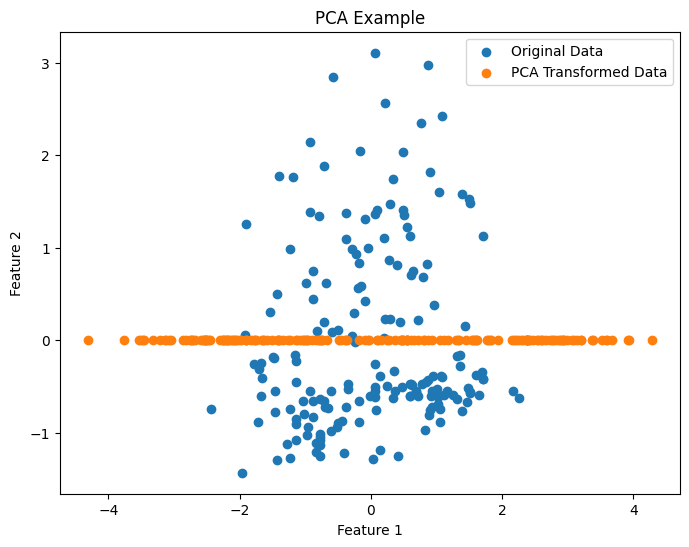

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt

# Sample data
wine = load_wine()
X = wine.data
print(X)

# Step 1: Standardize the Data
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Step 2: Compute the Covariance Matrix
cov_matrix = np.cov(X_standardized.T)

# Step 3: Compute the Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Step 4: Sort Eigenvalues and Eigenvectors
sorted_index = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

# Step 5: Transform the Data
k = 1  # Number of principal components
eigenvector_subset = sorted_eigenvectors[:, 0:k]
X_reduced = np.dot(X_standardized, eigenvector_subset)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X_standardized[:, 0], X_standardized[:, 1], label='Original Data')
plt.scatter(X_reduced, np.zeros_like(X_reduced), label='PCA Transformed Data')
plt.legend()
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('PCA Example')
plt.show()